In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, re, glob
import numpy as np
import pandas as pd

DATASET_ROOT = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion"

In [4]:
TEMP_FOLDERS = ["25degC"]
INCLUDE_TESTS = None
SAMPLE_EVERY_N = 10
RATED_CAPACITY_AH = 3.0

assert os.path.isdir(DATASET_ROOT), \
    f"Couldn't find {DATASET_ROOT}. Check that 'Dataset_Li-ion' is in your My Drive."


In [5]:
TEMP_MAP = {"n20degC": -20, "n10degC": -10, "0degC": 0,
            "10degC": 10, "25degC": 25, "40degC": 40}

file_records = []
for temp_folder in TEMP_FOLDERS:
    folder_path = os.path.join(DATASET_ROOT, temp_folder)
    if not os.path.isdir(folder_path):
        print(f"⚠️  Folder not found, skipping: {folder_path}")
        continue
    for f in sorted(glob.glob(os.path.join(folder_path, "*.csv"))):
        fname = os.path.basename(f)

        m = re.match(r"^\d+_(.+)\.csv$", fname)
        test_type = m.group(1) if m else fname.replace(".csv", "")
        if INCLUDE_TESTS is not None and test_type not in INCLUDE_TESTS:
            continue
        file_records.append({
            "path": f,
            "ambient_temp_c": TEMP_MAP[temp_folder],
            "test_type": test_type,
            "file_id": f"{temp_folder}_{test_type}",
        })

print(f"Found {len(file_records)} files to load:")
for r in file_records:
    print(" -", r["file_id"], "->", r["path"])

Found 36 files to load:
 - 25degC_C20DisCh -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/549_C20DisCh.csv
 - 25degC_Charge -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/549_Charge.csv
 - 25degC_Dis_0p5C -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/549_Dis_0p5C.csv
 - 25degC_Dis_2C -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/549_Dis_2C.csv
 - 25degC_HPPC -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/549_HPPC.csv
 - 25degC_Cap_1C -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/551_Cap_1C.csv
 - 25degC_Charge1 -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/551_Charge1.csv
 - 25degC_Charge2 -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/551_Charge2.csv
 - 25degC_Charge3 -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion/25degC/551_Charge3.csv
 - 25degC_Charge4 -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/Da

In [6]:
DATA_HEADER_PREFIX = "Time Stamp,Step,Status"

def load_battery_csv(path, ambient_temp_c, test_type, file_id, sample_every_n=1):
    with open(path, "r", errors="ignore") as fh:
        lines = fh.readlines()

    header_idx = next(i for i, l in enumerate(lines) if l.startswith(DATA_HEADER_PREFIX))
    df = pd.read_csv(path, skiprows=header_idx, header=0, low_memory=False)


    df = df.iloc[1:].reset_index(drop=True)


    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

    df.columns = [c.strip() for c in df.columns]
    rename_map = {
        "Time Stamp": "timestamp", "Step": "step", "Status": "status",
        "Prog Time": "prog_time", "Step Time": "step_time",
        "Cycle": "cycle", "Cycle Level": "cycle_level", "Procedure": "procedure",
        "Voltage": "voltage_v", "Current": "current_a",
        "Temperature": "cell_temp_c", "Capacity": "capacity_ah",
        "WhAccu": "wh_accu", "Cnt": "cnt",
    }
    df = df.rename(columns=rename_map)

    numeric_cols = ["voltage_v", "current_a", "cell_temp_c", "capacity_ah", "wh_accu", "cnt"]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if sample_every_n > 1:
        df = df.iloc[::sample_every_n].reset_index(drop=True)

    df["ambient_temp_c"] = ambient_temp_c
    df["test_type"] = test_type
    df["file_id"] = file_id
    return df

frames = []
for r in file_records:
    print(f"Loading {r['file_id']} ...")
    frames.append(load_battery_csv(r["path"], r["ambient_temp_c"], r["test_type"],
                                    r["file_id"], SAMPLE_EVERY_N))

df = pd.concat(frames, ignore_index=True)
print(f"\nCombined shape: {df.shape}")
df.head()

Loading 25degC_C20DisCh ...
Loading 25degC_Charge ...
Loading 25degC_Dis_0p5C ...
Loading 25degC_Dis_2C ...
Loading 25degC_HPPC ...
Loading 25degC_Cap_1C ...
Loading 25degC_Charge1 ...
Loading 25degC_Charge2 ...
Loading 25degC_Charge3 ...
Loading 25degC_Charge4 ...
Loading 25degC_Charge5 ...
Loading 25degC_Charge6 ...
Loading 25degC_Charge7 ...
Loading 25degC_Charge8 ...
Loading 25degC_HWFET ...
Loading 25degC_LA92 ...
Loading 25degC_Mixed1 ...
Loading 25degC_Mixed2 ...
Loading 25degC_UDDS ...
Loading 25degC_US06 ...
Loading 25degC_Cap_1C ...
Loading 25degC_Charge10 ...
Loading 25degC_Charge11 ...
Loading 25degC_Charge12 ...
Loading 25degC_Charge13 ...
Loading 25degC_Charge14 ...
Loading 25degC_Charge15 ...
Loading 25degC_Charge16 ...
Loading 25degC_Charge9 ...
Loading 25degC_Mixed3 ...
Loading 25degC_Mixed4 ...
Loading 25degC_Mixed5 ...
Loading 25degC_Mixed6 ...
Loading 25degC_Mixed7 ...
Loading 25degC_Mixed8 ...
Loading 25degC_PausCycl ...

Combined shape: (104560, 17)


,timestamp,step,status,prog_time,step_time,cycle,cycle_level,procedure,voltage_v,current_a,cell_temp_c,capacity_ah,wh_accu,cnt,ambient_temp_c,test_type,file_id
0,10/26/2018 9:29:22 AM,22.0,DCH,29:20:19.688,00:01:00.002,0.0,0.0,LG_HG2_NN_Char,4.17604,-0.15069,23.97615,-0.00254,-0.01060,13.0,25,C20DisCh,25degC_C20DisCh
1,10/26/2018 9:39:22 AM,22.0,DCH,29:30:19.686,00:11:00.000,0.0,0.0,LG_HG2_NN_Char,4.15244,-0.15325,23.76583,-0.02787,-0.11609,13.0,25,C20DisCh,25degC_C20DisCh
2,10/26/2018 9:49:22 AM,22.0,DCH,29:40:19.687,00:21:00.001,0.0,0.0,LG_HG2_NN_Char,4.13542,-0.15325,23.87099,-0.05325,-0.22124,13.0,25,C20DisCh,25degC_C20DisCh
3,10/26/2018 9:59:22 AM,22.0,DCH,29:50:19.685,00:30:59.999,0.0,0.0,LG_HG2_NN_Char,4.12244,-0.15325,23.76583,-0.07859,-0.32586,13.0,25,C20DisCh,25degC_C20DisCh
4,10/26/2018 10:09:22 AM,22.0,DCH,30:00:19.686,00:41:00.000,0.0,0.0,LG_HG2_NN_Char,4.11216,-0.15069,23.87099,-0.10393,-0.43017,13.0,25,C20DisCh,25degC_C20DisCh


In [7]:
print("DTYPES:")
print(df.dtypes)
print("\nMISSING VALUES:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDUPLICATE ROWS (exact): {df.duplicated().sum()}")
print("\nSTATUS VALUE COUNTS (PAU=pause, DCH=discharge, CHA=charge):")
print(df["status"].value_counts())
print("\nRows per file:")
print(df["file_id"].value_counts())

DTYPES:
timestamp          object
step              float64
status             object
prog_time          object
step_time          object
cycle             float64
cycle_level       float64
procedure          object
voltage_v         float64
current_a         float64
cell_temp_c       float64
capacity_ah       float64
wh_accu           float64
cnt               float64
ambient_temp_c      int64
test_type          object
file_id            object
dtype: object

MISSING VALUES:
Series([], dtype: int64)

DUPLICATE ROWS (exact): 0

STATUS VALUE COUNTS (PAU=pause, DCH=discharge, CHA=charge):
status
TABLE    85516
PAU      16989
CHA       1335
DCH        719
STO          1
Name: count, dtype: int64

Rows per file:
file_id
25degC_UDDS        15965
25degC_LA92        10077
25degC_Mixed8       8592
25degC_Mixed4       8085
25degC_Mixed2       7918
25degC_Mixed6       7811
25degC_Mixed1       7723
25degC_Mixed3       7383
25degC_Mixed7       7324
25degC_Mixed5       7219
25degC_PausCycl     6302

In [8]:
df_clean = df.copy()

before_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before_rows - len(df_clean)} exact duplicate rows "
      f"(these occur at step-transition boundaries in the raw logger output).")


before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=["voltage_v", "current_a", "cell_temp_c", "capacity_ah"])
print(f"Dropped {before_rows - len(df_clean)} rows with missing sensor values.")

print(f"\nFinal shape after cleaning: {df_clean.shape}")

Dropped 0 exact duplicate rows (these occur at step-transition boundaries in the raw logger output).
Dropped 0 rows with missing sensor values.

Final shape after cleaning: (104560, 17)


In [9]:
df_clean["soc_percent"] = (100 * (1 + df_clean["capacity_ah"] / RATED_CAPACITY_AH)).clip(0, 100)

df_clean["power_w"] = df_clean["voltage_v"] * df_clean["current_a"]

TARGET_COLUMN = "soc_percent"

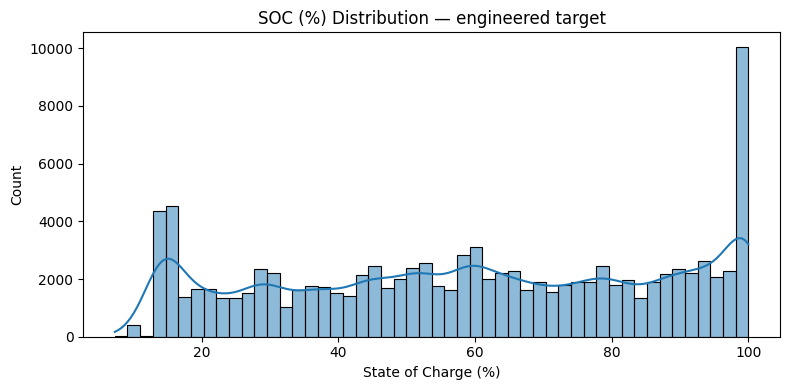


SOC summary stats:
count    104560.000000
mean         59.327616
std          27.726841
min           7.308667
25%          36.007833
50%          59.765833
75%          84.371667
max         100.000000
Name: soc_percent, dtype: float64


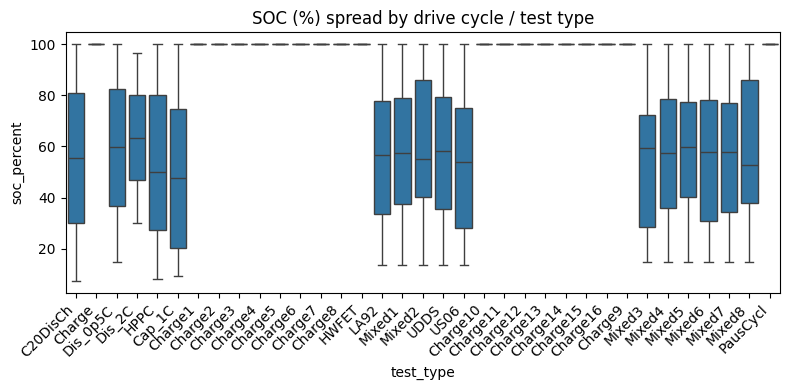

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COLUMN], bins=50, kde=True)
plt.title("SOC (%) Distribution — engineered target")
plt.xlabel("State of Charge (%)")
plt.tight_layout()
plt.show()

print("\nSOC summary stats:")
print(df_clean[TARGET_COLUMN].describe())

plt.figure(figsize=(8, 4))
sns.boxplot(x="test_type", y=TARGET_COLUMN, data=df_clean)
plt.title("SOC (%) spread by drive cycle / test type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


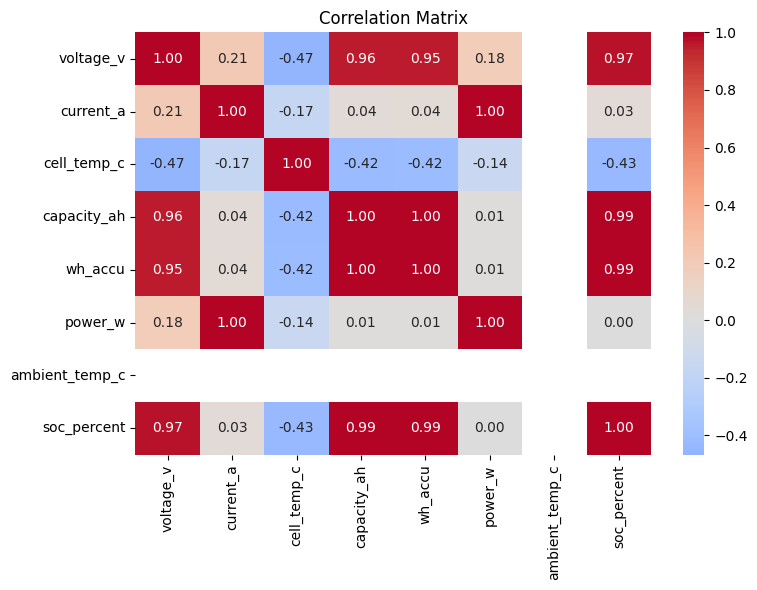


Correlation with target (SOC %):
capacity_ah       0.991209
wh_accu           0.988676
voltage_v         0.966963
cell_temp_c      -0.428164
current_a         0.031886
power_w           0.004905
ambient_temp_c         NaN
Name: soc_percent, dtype: float64


In [11]:
corr_cols = ["voltage_v", "current_a", "cell_temp_c", "capacity_ah",
             "wh_accu", "power_w", "ambient_temp_c", TARGET_COLUMN]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with target (SOC %):")
print(corr_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False))

In [12]:
print("\n===== LEAKAGE CHECKS =====")


LEAKAGE_THRESHOLD = 0.95
leak_corr = corr_matrix[TARGET_COLUMN].drop(TARGET_COLUMN)
suspects = leak_corr[abs(leak_corr) > LEAKAGE_THRESHOLD]
print(f"⚠️  Features with |correlation| > {LEAKAGE_THRESHOLD} with target:")
print(suspects if len(suspects) else "  (none)")
print("Note: capacity_ah is EXPECTED to correlate ~1.0 with SOC because SOC "
      "was derived from it directly — this is definitional leakage, not a "
      "coincidence to investigate. Same applies to wh_accu. Both must be "
      "excluded from the feature set.")


dup_cols = []
cols = df_clean.select_dtypes(include="number").columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df_clean[cols[i]].equals(df_clean[cols[j]]):
            dup_cols.append((cols[i], cols[j]))
print(f"\n{'⚠️ Duplicate columns: ' + str(dup_cols) if dup_cols else '✅ No exact duplicate numeric columns.'}")

print("\n⚠️  TEMPORAL LEAKAGE RISK: rows within a file are a dense time series "
      "(consecutive rows differ by ~0.1-1s). A random row-level train/test "
      "split would put near-identical neighboring samples on both sides. "
      "Split must be done by whole file/test (see Cell 10), not by row.")

FEATURE_COLUMNS = ["voltage_v", "current_a", "cell_temp_c", "power_w", "ambient_temp_c"]
EXCLUDED_AS_LEAKAGE = ["capacity_ah", "wh_accu", "cnt", "step", "cycle",
                        "cycle_level", "procedure", "status", "prog_time", "step_time"]
print(f"\nFinal feature set: {FEATURE_COLUMNS}")
print(f"Excluded (leakage or test-control artifacts, not available at "
      f"real-world prediction time): {EXCLUDED_AS_LEAKAGE}")



===== LEAKAGE CHECKS =====
⚠️  Features with |correlation| > 0.95 with target:
voltage_v      0.966963
capacity_ah    0.991209
wh_accu        0.988676
Name: soc_percent, dtype: float64
Note: capacity_ah is EXPECTED to correlate ~1.0 with SOC because SOC was derived from it directly — this is definitional leakage, not a coincidence to investigate. Same applies to wh_accu. Both must be excluded from the feature set.

✅ No exact duplicate numeric columns.

⚠️  TEMPORAL LEAKAGE RISK: rows within a file are a dense time series (consecutive rows differ by ~0.1-1s). A random row-level train/test split would put near-identical neighboring samples on both sides. Split must be done by whole file/test (see Cell 10), not by row.

Final feature set: ['voltage_v', 'current_a', 'cell_temp_c', 'power_w', 'ambient_temp_c']
Excluded (leakage or test-control artifacts, not available at real-world prediction time): ['capacity_ah', 'wh_accu', 'cnt', 'step', 'cycle', 'cycle_level', 'procedure', 'status', '

In [13]:
from sklearn.model_selection import GroupShuffleSplit

X = df_clean[FEATURE_COLUMNS]
y = df_clean[TARGET_COLUMN]
groups = df_clean["file_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train files:", sorted(df_clean.iloc[train_idx]['file_id'].unique()))
print("Test files:", sorted(df_clean.iloc[test_idx]['file_id'].unique()))
print("\nJustification: split is grouped by whole test file (GroupShuffleSplit), "
      "so no drive cycle appears in both train and test — this respects the "
      "time-series/autocorrelated nature of the data and avoids the temporal "
      "leakage flagged above. A plain random 80/20 row split would have been "
      "invalid for this dataset.")


Train shape: (76792, 5), Test shape: (27768, 5)
Train files: ['25degC_C20DisCh', '25degC_Cap_1C', '25degC_Charge', '25degC_Charge1', '25degC_Charge10', '25degC_Charge11', '25degC_Charge12', '25degC_Charge13', '25degC_Charge14', '25degC_Charge15', '25degC_Charge16', '25degC_Charge2', '25degC_Charge3', '25degC_Charge5', '25degC_Charge7', '25degC_Charge8', '25degC_Charge9', '25degC_Dis_2C', '25degC_HWFET', '25degC_LA92', '25degC_Mixed2', '25degC_Mixed4', '25degC_Mixed5', '25degC_Mixed7', '25degC_Mixed8', '25degC_PausCycl', '25degC_UDDS', '25degC_US06']
Test files: ['25degC_Charge4', '25degC_Charge6', '25degC_Dis_0p5C', '25degC_HPPC', '25degC_Mixed1', '25degC_Mixed3', '25degC_Mixed6']

Justification: split is grouped by whole test file (GroupShuffleSplit), so no drive cycle appears in both train and test — this respects the time-series/autocorrelated nature of the data and avoids the temporal leakage flagged above. A plain random 80/20 row split would have been invalid for this dataset.


In [14]:
import datetime

VERSION_NAME = "dataset_v1"
os.makedirs("frozen_dataset", exist_ok=True)

df_clean.to_csv(f"frozen_dataset/{VERSION_NAME}_full.csv", index=False)
X_train.assign(soc_percent=y_train, file_id=df_clean.iloc[train_idx]["file_id"].values) \
    .to_csv(f"frozen_dataset/{VERSION_NAME}_train.csv", index=False)
X_test.assign(soc_percent=y_test, file_id=df_clean.iloc[test_idx]["file_id"].values) \
    .to_csv(f"frozen_dataset/{VERSION_NAME}_test.csv", index=False)

with open(f"frozen_dataset/{VERSION_NAME}_summary.txt", "w") as f:
    f.write("Dataset Version: V1\n")
    f.write(f"Frozen on: {datetime.datetime.now()}\n")
    f.write(f"Source: LG 18650HG2 Li-ion battery dataset, folders: {TEMP_FOLDERS}\n")
    f.write(f"Test types included: {INCLUDE_TESTS or 'all'}\n")
    f.write(f"Downsampling: every {SAMPLE_EVERY_N} rows\n")
    f.write(f"Final shape: {df_clean.shape}\n")
    f.write(f"Target: soc_percent, derived as 100*(1 + capacity_ah/{RATED_CAPACITY_AH}), clipped [0,100]\n")
    f.write(f"Feature columns: {FEATURE_COLUMNS}\n")
    f.write(f"Excluded as leakage/artifacts: {EXCLUDED_AS_LEAKAGE}\n")
    f.write(f"Split method: GroupShuffleSplit by file_id, test_size=0.2, random_state=42\n")
    f.write(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")

print("\n✅ Dataset V1 frozen. Files saved in 'frozen_dataset/':")
for f in os.listdir("frozen_dataset"):
    print(" -", f)



✅ Dataset V1 frozen. Files saved in 'frozen_dataset/':
 - dataset_v1_summary.txt
 - dataset_v1_test.csv
 - dataset_v1_train.csv
 - dataset_v1_full.csv


In [15]:
get_ipython().system('cp -r frozen_dataset /content/drive/MyDrive/')